# DIGITAL TRANSACTION RISK ANALYSIS
## Unit IV: Correlation and Regression Analysis

In this unit, we transition from descriptive/inferential statistics to predictive modeling. We explore linear, polynomial, and logistic regression techniques to model transaction behavior and detect fraud. We evaluate these models using standard metrics like R-squared, MSE, Confusion Matrix, and the ROC Curve.

In [2]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA PREPARATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, auc

print("Loading dataset...")
try:
    df = pd.read_csv('fraudTrain.csv')
    
    # Feature Engineering (as per Unit 1) for modeling
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['transaction_hour'] = df['trans_date_trans_time'].dt.hour

    # Using a sample for faster execution during training (stratified)
    df_sample = df.groupby('is_fraud', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 20000), random_state=42))
    print(f"Using stratified sample of {len(df_sample)} records for modeling.")
except FileNotFoundError:
    print("Error: fraudTrain.csv not found.")


Loading dataset...
Using stratified sample of 27506 records for modeling.


C:\Users\shubh\AppData\Local\Temp\ipykernel_24056\2668746531.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('is_fraud', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 20000), random_state=42))


## 1. Simple Linear Regression
**Objective:** Predict the transaction amount (`amt`) using a single quantitative predictor, such as `city_pop`.

In [3]:
print('\n' + '='*60)
print('SIMPLE LINEAR REGRESSION (amt vs city_pop)')
print('='*60)

X_simple = df_sample[['city_pop']]
y_simple = df_sample['amt']

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)
y_pred_simple = model_simple.predict(X_simple)

print(f"Coefficient: {model_simple.coef_[0]:.6f}")
print(f"Intercept  : {model_simple.intercept_:.2f}")
print(f"R-squared  : {r2_score(y_simple, y_pred_simple):.4f}")
print(f"MSE        : {mean_squared_error(y_simple, y_pred_simple):.2f}")



SIMPLE LINEAR REGRESSION (amt vs city_pop)
Coefficient: 0.000019
Intercept  : 191.81
R-squared  : 0.0003
MSE        : 99641.55


## 2. Multiple and Polynomial Regression
**Objective:** Predict `amt` using multiple variables and explore non-linear relationships with polynomial features.

In [4]:
print('\n' + '='*60)
print('MULTIPLE AND POLYNOMIAL REGRESSION')
print('='*60)

# Multiple Linear Regression
X_mult = df_sample[['city_pop', 'lat', 'long', 'transaction_hour']]
model_mult = LinearRegression()
model_mult.fit(X_mult, y_simple)
print(f"Multiple R-squared: {r2_score(y_simple, model_mult.predict(X_mult)):.4f}")

# Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_simple)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_simple)
print(f"Polynomial R-squared (Degree 2): {r2_score(y_simple, model_poly.predict(X_poly)):.4f}")



MULTIPLE AND POLYNOMIAL REGRESSION
Multiple R-squared: 0.0383
Polynomial R-squared (Degree 2): 0.0004


## 3. Logistic Regression for Fraud Detection
**Objective:** Classify transactions as Fraud (1) or Legitimate (0) based on transaction features.

In [5]:
print('\n' + '='*60)
print('LOGISTIC REGRESSION: FRAUD CLASSIFICATION')
print('='*60)

# Prepare features and target
features = ['amt', 'city_pop', 'transaction_hour', 'lat', 'long']
X = df_sample[features]
y = df_sample['is_fraud']

# Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)
y_pred = model_log.predict(X_test)
y_prob = model_log.predict_proba(X_test)[:, 1]

print("Logistic Regression Training Complete.")



LOGISTIC REGRESSION: FRAUD CLASSIFICATION
Logistic Regression Training Complete.


## 4. Model Evaluation (Confusion Matrix and ROC Curve)
**Objective:** Evaluate the classification performance using specialized metrics.


EVALUATION METRICS


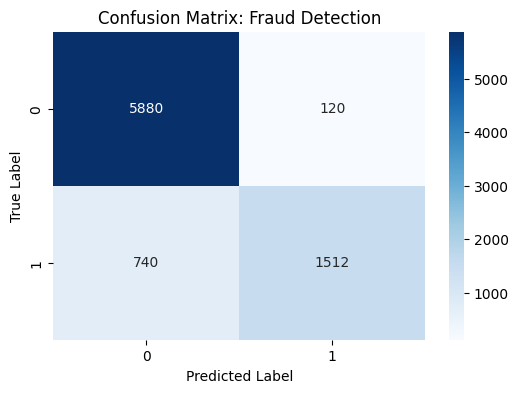

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      6000
           1       0.93      0.67      0.78      2252

    accuracy                           0.90      8252
   macro avg       0.91      0.83      0.86      8252
weighted avg       0.90      0.90      0.89      8252



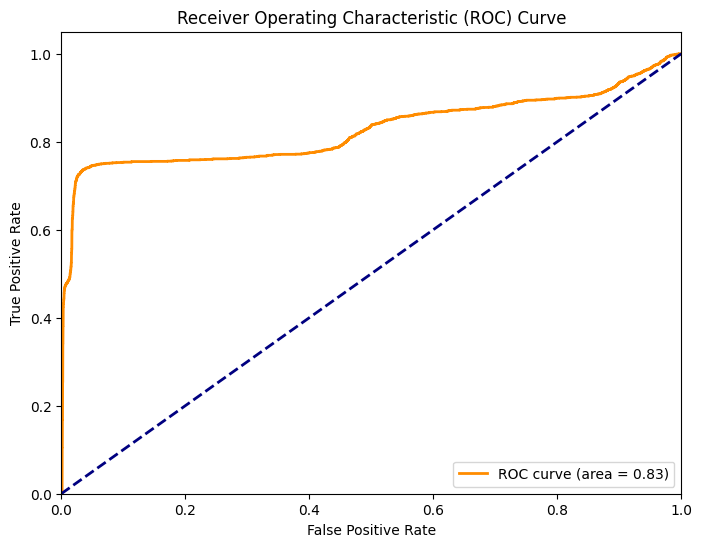


ROC-AUC Score: 0.8264
Interpretation: The AUC score represents the model's ability to distinguish between fraud and legitimate cases.
UNIT IV COMPLETE


In [6]:
print('\n' + '='*60)
print('EVALUATION METRICS')
print('='*60)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Fraud Detection')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print("Interpretation: The AUC score represents the model's ability to distinguish between fraud and legitimate cases.")
print("=" * 60)
print("UNIT IV COMPLETE")
print("=" * 60)
